In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
input_path = "../outputs/kpi_dataset.csv"
output_folder = "../outputs"
output_path = "../outputs/weekly_trends.csv"

os.makedirs(output_folder, exist_ok=True)
df = pd.read_csv(input_path)

# Convert post_date again because CSV saves dates as text
df["post_date"] = pd.to_datetime(df["post_date"], errors="coerce")

# Preview data
df.head()

c:\Users\hanai\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\hanai\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,business_name,sector,followers_count,post_date,posting_hour,day_of_week,month,post_type,caption_text,caption_length,...,discount_percent,mentions_location,religious_theme,patriotic_theme,arabic_dialect_style,engagement,engagement_rate,week,is_video,is_reel
0,Shifa Physiotherapy,Clinic,10435,2025-06-03,17,Tuesday,6,image,"Support local, shop Palestinian. #Jerusalem #H...",76,...,0.0,False,False,False,False,433.0,0.041495,2025-06-02/2025-06-08,False,False
1,Falafel Al-Balad,Restaurant,11524,2025-06-05,20,Thursday,6,image,Limited offer for this week. Book now ?????,43,...,0.0,False,True,False,False,604.0,0.052412,2025-06-02/2025-06-08,False,False
2,Gaza Home Cleaning,Local Services,2776,2025-06-05,22,Thursday,6,carousel,Community vibes in Ramallah. ?????,34,...,0.0,True,False,False,False,119.0,0.042867,2025-06-02/2025-06-08,False,False
3,Gaza Sea Breeze Cafe,Cafe,14649,2025-06-06,21,Friday,6,reel,Customer favorite is back. Visit us today | ah...,111,...,4.0,False,False,False,True,2048.1,0.139812,2025-06-02/2025-06-08,False,True
4,Cafe Al-Quds,Cafe,12976,2025-06-07,3,Saturday,6,carousel,"Support local, shop Palestinian. Order on What...",66,...,24.0,False,False,True,False,247.0,0.019035,2025-06-02/2025-06-08,False,False


### Create weekly trends table

In [2]:
weekly_trends = (
    df.groupby("week")
    .agg(
        start_date=("post_date", "min"),
        end_date=("post_date", "max"),
        total_posts=("post_date", "count"),
        total_likes=("likes_count", "sum"),
        total_comments=("comments_count", "sum"),
        total_views=("views_count", "sum"),
        total_engagement=("engagement", "sum"),
        avg_engagement=("engagement", "mean"),
        avg_engagement_rate=("engagement_rate", "mean"),
        avg_followers=("followers_count", "mean")
    )
    .reset_index()
)

weekly_trends.head()

,week,start_date,end_date,total_posts,total_likes,total_comments,total_views,total_engagement,avg_engagement,avg_engagement_rate,avg_followers
0,2025-06-02/2025-06-08,2025-06-03,2025-06-07,6,1968,165,29748.0,5272.8,878.800000,0.083141,10220.666667
1,2025-06-09/2025-06-15,2025-06-09,2025-06-13,3,1134,113,0.0,1360.0,453.333333,0.032483,13439.333333
2,2025-06-16/2025-06-22,2025-06-16,2025-06-22,8,2733,198,36332.0,6762.2,845.275000,0.108387,8931.875000
3,2025-06-23/2025-06-29,2025-06-23,2025-06-29,9,1860,154,33399.0,5507.9,611.988889,0.074066,6959.555556
4,2025-06-30/2025-07-06,2025-07-01,2025-07-06,7,1366,91,14547.0,3002.7,428.957143,0.091242,6851.142857


### Add week over week change

In [3]:
# Difference in engagement compared to previous week
weekly_trends["engagement_change"] = weekly_trends["total_engagement"].diff()

# Percentage change compared to previous week
weekly_trends["engagement_change_pct"] = (
    weekly_trends["total_engagement"].pct_change() * 100
)

# Replace missing values in the first week with 0
weekly_trends["engagement_change"] = weekly_trends["engagement_change"].fillna(0)
weekly_trends["engagement_change_pct"] = weekly_trends["engagement_change_pct"].fillna(0)

weekly_trends.head()

,week,start_date,end_date,total_posts,total_likes,total_comments,total_views,total_engagement,avg_engagement,avg_engagement_rate,avg_followers,engagement_change,engagement_change_pct
0,2025-06-02/2025-06-08,2025-06-03,2025-06-07,6,1968,165,29748.0,5272.8,878.800000,0.083141,10220.666667,0.0,0.000000
1,2025-06-09/2025-06-15,2025-06-09,2025-06-13,3,1134,113,0.0,1360.0,453.333333,0.032483,13439.333333,-3912.8,-74.207252
2,2025-06-16/2025-06-22,2025-06-16,2025-06-22,8,2733,198,36332.0,6762.2,845.275000,0.108387,8931.875000,5402.2,397.220588
3,2025-06-23/2025-06-29,2025-06-23,2025-06-29,9,1860,154,33399.0,5507.9,611.988889,0.074066,6959.555556,-1254.3,-18.548697
4,2025-06-30/2025-07-06,2025-07-01,2025-07-06,7,1366,91,14547.0,3002.7,428.957143,0.091242,6851.142857,-2505.2,-45.483760


### Add trend status

In [4]:
def classify_trend(change_pct):
    """
    Classify weekly performance based on engagement percentage change.
    """
    if change_pct > 10:
        return "improving"
    elif change_pct < -10:
        return "declining"
    else:
        return "stable"


weekly_trends["trend_status"] = weekly_trends["engagement_change_pct"].apply(classify_trend)

weekly_trends.head()

,week,start_date,end_date,total_posts,total_likes,total_comments,total_views,total_engagement,avg_engagement,avg_engagement_rate,avg_followers,engagement_change,engagement_change_pct,trend_status
0,2025-06-02/2025-06-08,2025-06-03,2025-06-07,6,1968,165,29748.0,5272.8,878.800000,0.083141,10220.666667,0.0,0.000000,stable
1,2025-06-09/2025-06-15,2025-06-09,2025-06-13,3,1134,113,0.0,1360.0,453.333333,0.032483,13439.333333,-3912.8,-74.207252,declining
2,2025-06-16/2025-06-22,2025-06-16,2025-06-22,8,2733,198,36332.0,6762.2,845.275000,0.108387,8931.875000,5402.2,397.220588,improving
3,2025-06-23/2025-06-29,2025-06-23,2025-06-29,9,1860,154,33399.0,5507.9,611.988889,0.074066,6959.555556,-1254.3,-18.548697,declining
4,2025-06-30/2025-07-06,2025-07-01,2025-07-06,7,1366,91,14547.0,3002.7,428.957143,0.091242,6851.142857,-2505.2,-45.483760,declining


### Find best and worst weeks

In [5]:
best_week = weekly_trends.loc[weekly_trends["total_engagement"].idxmax()]
worst_week = weekly_trends.loc[weekly_trends["total_engagement"].idxmin()]

print("Best week:")
print(best_week[["week", "total_engagement", "total_posts", "trend_status"]])

print("\nWorst week:")
print(worst_week[["week", "total_engagement", "total_posts", "trend_status"]])

Best week:
week                2026-03-02/2026-03-08
total_engagement                  10527.4
total_posts                             9
trend_status                    improving
Name: 39, dtype: object

Worst week:
week                2025-08-18/2025-08-24
total_engagement                    450.0
total_posts                             3
trend_status                    declining
Name: 11, dtype: object


### Save weekly trends output

In [6]:
weekly_trends.to_csv(output_path, index=False)

print("Phase 2 completed successfully.")
print("Weekly trends saved to:", output_path)
print("Output shape:", weekly_trends.shape)

Phase 2 completed successfully.
Weekly trends saved to: ../outputs/weekly_trends.csv
Output shape: (41, 14)


Visualizations parrt

Weekly Total Engagement

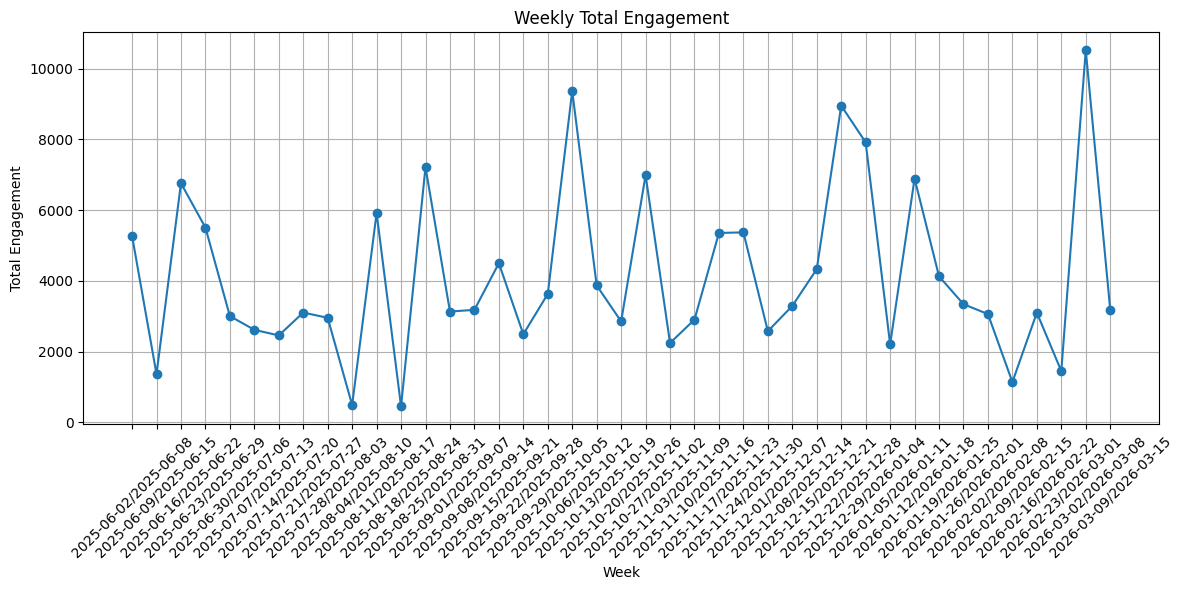

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    weekly_trends["week"],
    weekly_trends["total_engagement"],
    marker="o"
)

plt.title("Weekly Total Engagement")
plt.xlabel("Week")
plt.ylabel("Total Engagement")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

This chart shows the weekly total engagement trend. It helps identify whether overall audience interaction is increasing, decreasing, or remaining stable over time. Peaks indicate strong-performing weeks, while drops may suggest weaker content performance or lower posting impact.

Week-over-Week Engagement Change Percentage

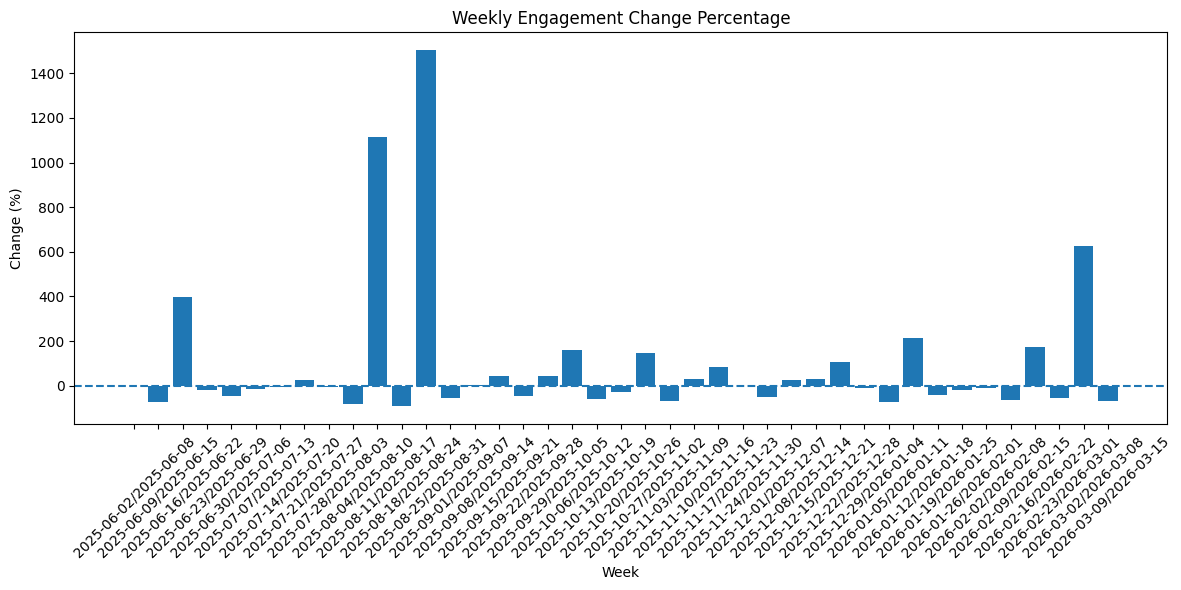

In [9]:
plt.figure(figsize=(12, 6))

plt.bar(
    weekly_trends["week"],
    weekly_trends["engagement_change_pct"]
)

plt.axhline(0, linestyle="--")

plt.title("Weekly Engagement Change Percentage")
plt.xlabel("Week")
plt.ylabel("Change (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

This chart shows the week-over-week percentage change in engagement. Positive values indicate improvement compared to the previous week, while negative values indicate decline. It helps quickly detect growth periods and performance drops.

Weekly Likes, Comments, and Views

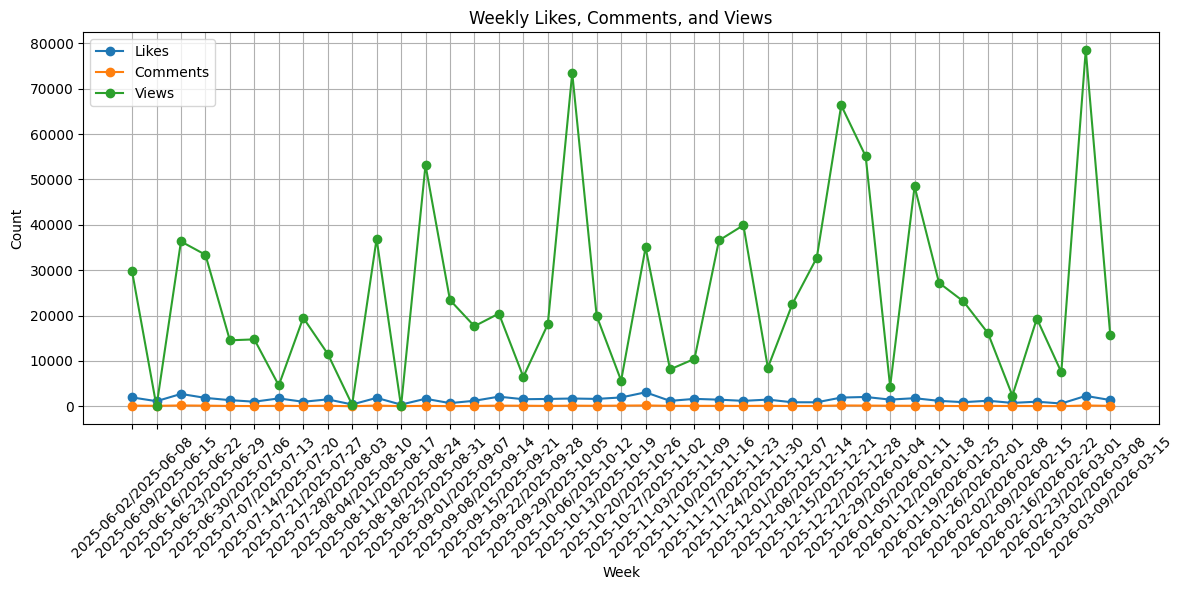

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(weekly_trends["week"], weekly_trends["total_likes"], marker="o", label="Likes")
plt.plot(weekly_trends["week"], weekly_trends["total_comments"], marker="o", label="Comments")
plt.plot(weekly_trends["week"], weekly_trends["total_views"], marker="o", label="Views")

plt.title("Weekly Likes, Comments, and Views")
plt.xlabel("Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

This chart compares weekly likes, comments, and views. It helps identify which engagement component contributes most to performance. For example, high views with low comments may indicate strong reach but weak audience interaction.

Weekly Average Engagement Rate

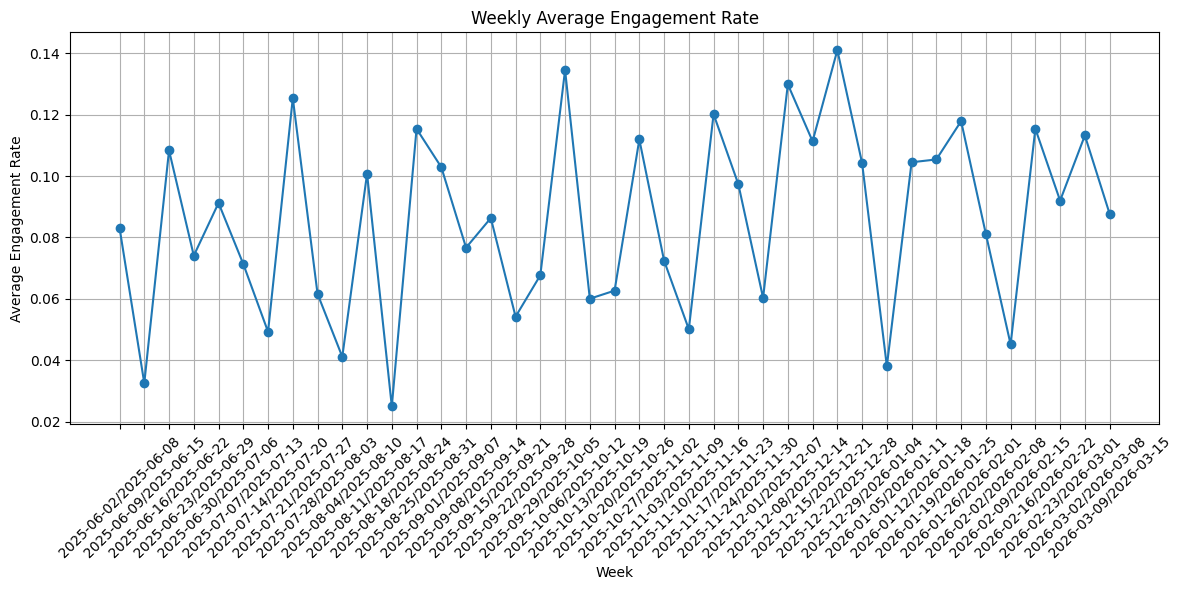

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    weekly_trends["week"],
    weekly_trends["avg_engagement_rate"],
    marker="o"
)

plt.title("Weekly Average Engagement Rate")
plt.xlabel("Week")
plt.ylabel("Average Engagement Rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

This chart shows the average weekly engagement rate, which normalizes engagement by follower count. It provides a fairer performance comparison across businesses with different audience sizes.